# Tratamento e analise de dados com Pandas

**Dataset:** Wine Quality - Red Wine, do UCI Machine Learning Repository.

O objetivo deste notebook e descrever os dados, identificar problemas de qualidade, aplicar tratamento com Pandas e responder 10 perguntas usando filtragens, agrupamentos e transformacoes.

## 1. Carregamento das bibliotecas e do dataset

O arquivo bruto foi salvo na pasta `data/` do repositorio. Ele usa ponto e virgula como separador.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
DATA_PATH = "../data/winequality-red.csv"
df_original = pd.read_csv(DATA_PATH, sep=";")

print(f"Linhas: {df_original.shape[0]}")
print(f"Colunas: {df_original.shape[1]}")
display(df_original.head())

Linhas: 1599
Colunas: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Descricao inicial dos dados

A tabela abaixo resume tipos, quantidade de nulos e valores distintos por coluna.

In [3]:
descricao_inicial = pd.DataFrame({
    "tipo": df_original.dtypes.astype(str),
    "nulos": df_original.isna().sum(),
    "valores_distintos": df_original.nunique(),
})

print(f"Linhas duplicadas no dataset bruto: {df_original.duplicated().sum()}")
display(descricao_inicial)
display(df_original.describe().T.round(3))

Linhas duplicadas no dataset bruto: 240


,tipo,nulos,valores_distintos
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


## 3. Tratamento de qualidade dos dados

Etapas aplicadas:

- Padronizacao dos nomes das colunas para `snake_case`.
- Remocao de linhas duplicadas.
- Remocao de colunas constantes, se existirem.
- Preenchimento de nulos numericos pela mediana, se existirem.
- Criacao de variaveis derivadas para apoiar a analise.

In [4]:
df = df_original.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

linhas_antes = len(df)
duplicadas_antes = int(df.duplicated().sum())
nulos_antes = int(df.isna().sum().sum())

df = df.drop_duplicates().reset_index(drop=True)

colunas_constantes = [
    coluna for coluna in df.columns
    if df[coluna].nunique(dropna=False) <= 1
]
if colunas_constantes:
    df = df.drop(columns=colunas_constantes)

for coluna in df.select_dtypes(include="number").columns:
    if df[coluna].isna().any():
        df[coluna] = df[coluna].fillna(df[coluna].median())

df["quality_class"] = pd.cut(
    df["quality"],
    bins=[0, 5, 6, 10],
    labels=["baixa", "media", "alta"],
    include_lowest=True,
)
df["alcohol_level"] = pd.qcut(
    df["alcohol"],
    q=3,
    labels=["baixo", "medio", "alto"],
)
df["volatile_acidity_level"] = pd.qcut(
    df["volatile_acidity"],
    q=3,
    labels=["baixa", "media", "alta"],
)
df["sulphates_group"] = [
    "alto" if valor >= df["sulphates"].median() else "baixo"
    for valor in df["sulphates"]
]

df.to_csv("../data/winequality-red-clean.csv", index=False)

relatorio_tratamento = pd.DataFrame({
    "item": [
        "linhas_antes",
        "linhas_depois",
        "duplicadas_removidas",
        "nulos_antes",
        "nulos_depois",
        "colunas_constantes_removidas",
    ],
    "valor": [
        linhas_antes,
        len(df),
        duplicadas_antes,
        nulos_antes,
        int(df.isna().sum().sum()),
        len(colunas_constantes),
    ],
})

display(relatorio_tratamento)
display(df.head())

,item,valor
0,linhas_antes,1599
1,linhas_depois,1359
2,duplicadas_removidas,240
3,nulos_antes,0
4,nulos_depois,0
5,colunas_constantes_removidas,0


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,quality_class,alcohol_level,volatile_acidity_level,sulphates_group
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,baixa,baixo,alta,baixo
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,baixa,medio,alta,alto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,baixa,medio,alta,alto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,media,medio,baixa,baixo
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,baixa,baixo,alta,baixo


## 4. Perguntas e respostas com Pandas

### Pergunta 1: Qual e o tamanho do dataset depois da limpeza?

In [5]:
print(f"Dataset bruto: {df_original.shape[0]} linhas e {df_original.shape[1]} colunas.")
print(f"Dataset tratado: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print(f"Foram removidas {duplicadas_antes} linhas duplicadas e {len(colunas_constantes)} colunas constantes.")

Dataset bruto: 1599 linhas e 12 colunas.
Dataset tratado: 1359 linhas e 16 colunas.
Foram removidas 240 linhas duplicadas e 0 colunas constantes.


### Pergunta 2: Como as notas de qualidade estao distribuidas?

,quantidade,percentual
quality,,
3,10,0.74
4,53,3.90
5,577,42.46
6,535,39.37
7,167,12.29
8,17,1.25


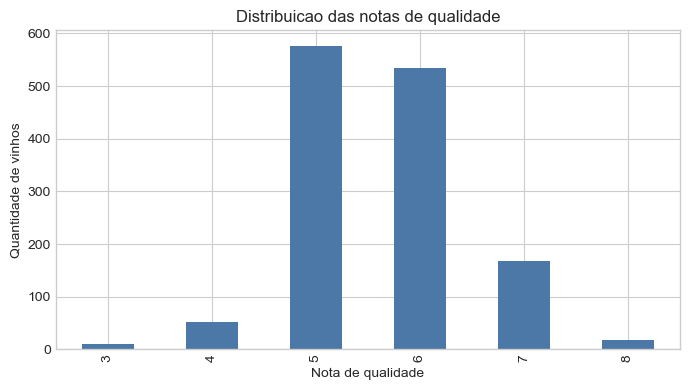

In [6]:
distribuicao_qualidade = (
    df["quality"]
    .value_counts()
    .sort_index()
    .rename_axis("quality")
    .to_frame("quantidade")
)
distribuicao_qualidade["percentual"] = (
    distribuicao_qualidade["quantidade"] / len(df) * 100
).round(2)

display(distribuicao_qualidade)

ax = distribuicao_qualidade["quantidade"].plot(
    kind="bar",
    figsize=(7, 4),
    color="#4c78a8",
    title="Distribuicao das notas de qualidade",
)
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Quantidade de vinhos")
plt.tight_layout()
plt.show()

### Pergunta 3: Qual e o teor alcoolico medio por nota de qualidade?

,quantidade,media,mediana
quality,,,
3,10,9.96,9.93
4,53,10.27,10.00
5,577,9.89,9.60
6,535,10.66,10.50
7,167,11.49,11.60
8,17,12.16,12.50


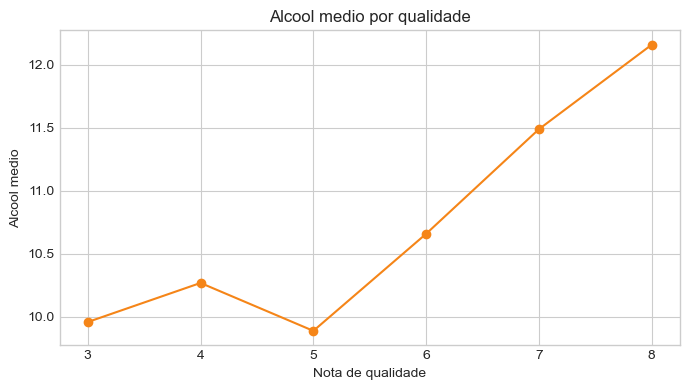

In [7]:
alcool_por_qualidade = (
    df.groupby("quality")["alcohol"]
    .agg(quantidade="count", media="mean", mediana="median")
    .round(2)
)
display(alcool_por_qualidade)

ax = alcool_por_qualidade["media"].plot(
    kind="line",
    marker="o",
    figsize=(7, 4),
    color="#f58518",
    title="Alcool medio por qualidade",
)
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Alcool medio")
plt.tight_layout()
plt.show()

### Pergunta 4: Vinhos de qualidade alta tem alcool medio maior que os demais?

In [8]:
alcool_por_classe = (
    df.groupby("quality_class", observed=True)["alcohol"]
    .agg(quantidade="count", media="mean", mediana="median")
    .round(2)
)
display(alcool_por_classe)

media_alta = df.loc[df["quality_class"] == "alta", "alcohol"].mean()
media_demais = df.loc[df["quality_class"] != "alta", "alcohol"].mean()
diferenca = media_alta - media_demais
print(f"Alcool medio dos vinhos de qualidade alta: {media_alta:.2f}")
print(f"Alcool medio dos demais vinhos: {media_demais:.2f}")
print(f"Diferenca: {diferenca:.2f} ponto percentual de alcool.")

,quantidade,media,mediana
quality_class,,,
baixa,640,9.92,9.7
media,535,10.66,10.5
alta,184,11.55,11.6


Alcool medio dos vinhos de qualidade alta: 11.55
Alcool medio dos demais vinhos: 10.26
Diferenca: 1.30 ponto percentual de alcool.


### Pergunta 5: Como a acidez volatil varia entre as classes de qualidade?

In [9]:
acidez_volatil = (
    df.groupby("quality_class", observed=True)["volatile_acidity"]
    .agg(quantidade="count", media="mean", mediana="median")
    .round(3)
)
correlacao_acidez = df[["volatile_acidity", "quality"]].corr().iloc[0, 1]

display(acidez_volatil)
print(f"Correlacao entre acidez volatil e qualidade: {correlacao_acidez:.3f}")

,quantidade,media,mediana
quality_class,,,
baixa,640,0.593,0.59
media,535,0.496,0.49
alta,184,0.406,0.37


Correlacao entre acidez volatil e qualidade: -0.395


### Pergunta 6: Quais variaveis numericas mais se relacionam com a qualidade?

,correlacao_com_quality
alcohol,0.480
volatile_acidity,-0.395
sulphates,0.249
citric_acid,0.228
density,-0.184
total_sulfur_dioxide,-0.178


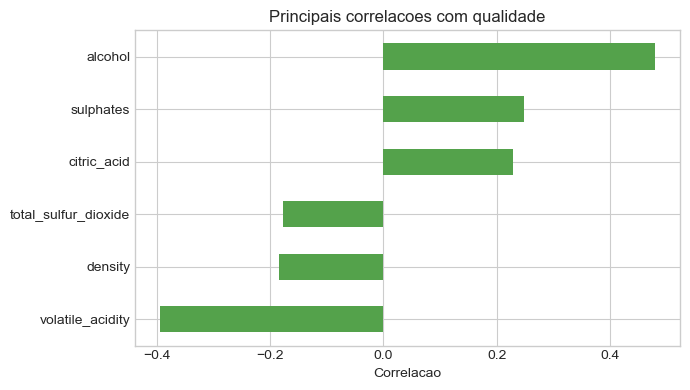

In [10]:
correlacoes = (
    df.select_dtypes(include="number")
    .corr()["quality"]
    .drop("quality")
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

top_correlacoes = correlacoes.head(6).to_frame("correlacao_com_quality").round(3)
display(top_correlacoes)

ax = top_correlacoes["correlacao_com_quality"].sort_values().plot(
    kind="barh",
    figsize=(7, 4),
    color="#54a24b",
    title="Principais correlacoes com qualidade",
)
ax.set_xlabel("Correlacao")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Pergunta 7: Qual e o perfil medio de vinhos baixos, medios e altos?

In [11]:
perfil_classes = (
    df.groupby("quality_class", observed=True)[
        ["alcohol", "volatile_acidity", "sulphates", "citric_acid", "density", "chlorides"]
    ]
    .mean()
    .round(3)
)
display(perfil_classes)

,alcohol,volatile_acidity,sulphates,citric_acid,density,chlorides
quality_class,,,,,,
baixa,9.921,0.593,0.620,0.238,0.997,0.094
media,10.659,0.496,0.675,0.279,0.997,0.085
alta,11.553,0.406,0.746,0.373,0.996,0.076


### Pergunta 8: Vinhos com sulfatos acima da mediana tem qualidade media maior?

In [12]:
sulfatos = (
    df.groupby("sulphates_group")["quality"]
    .agg(quantidade="count", qualidade_media="mean")
    .round(3)
)
taxa_alta_por_sulfatos = (
    df.assign(alta_qualidade=df["quality"] >= 7)
    .groupby("sulphates_group")["alta_qualidade"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("pct_qualidade_alta")
)

display(sulfatos)
display(taxa_alta_por_sulfatos)

,quantidade,qualidade_media
sulphates_group,,
alto,703,5.900
baixo,656,5.326


,pct_qualidade_alta
sulphates_group,
alto,22.62
baixo,3.81


### Pergunta 9: A combinacao de alcool alto e acidez volatil baixa esta associada a notas melhores?

In [13]:
limite_alcool_alto = df["alcohol"].quantile(0.75)
limite_acidez_baixa = df["volatile_acidity"].quantile(0.25)

df["segmento_alcool_acidez"] = "outros"
df.loc[
    (df["alcohol"] >= limite_alcool_alto)
    & (df["volatile_acidity"] <= limite_acidez_baixa),
    "segmento_alcool_acidez",
] = "alcool alto e acidez volatil baixa"

segmento = (
    df.groupby("segmento_alcool_acidez")["quality"]
    .agg(
        quantidade="count",
        qualidade_media="mean",
        pct_qualidade_alta=lambda serie: (serie >= 7).mean() * 100,
    )
    .round(2)
)
display(segmento)
print(f"Limite de alcool alto (quartil 75%): {limite_alcool_alto:.2f}")
print(f"Limite de acidez volatil baixa (quartil 25%): {limite_acidez_baixa:.2f}")

,quantidade,qualidade_media,pct_qualidade_alta
segmento_alcool_acidez,,,
alcool alto e acidez volatil baixa,142,6.42,47.18
outros,1217,5.53,9.61


Limite de alcool alto (quartil 75%): 11.10
Limite de acidez volatil baixa (quartil 25%): 0.39


### Pergunta 10: Qual faixa de alcool apresenta melhor qualidade media?

In [14]:
df["faixa_alcool"] = pd.cut(
    df["alcohol"],
    bins=[0, 9.5, 10.5, 11.5, 20],
    labels=["ate_9_5", "9_5_a_10_5", "10_5_a_11_5", "acima_11_5"],
)

faixas_alcool = (
    df.groupby("faixa_alcool", observed=True)
    .agg(
        quantidade=("quality", "size"),
        qualidade_media=("quality", "mean"),
        pct_qualidade_alta=("quality", lambda serie: (serie >= 7).mean() * 100),
    )
    .round(2)
)
display(faixas_alcool)

,quantidade,qualidade_media,pct_qualidade_alta
faixa_alcool,,,
ate_9_5,374,5.23,0.80
9_5_a_10_5,461,5.45,6.51
10_5_a_11_5,303,5.82,18.15
acima_11_5,221,6.38,43.44


## 5. Conclusoes

- O dataset bruto nao possui valores nulos, mas possui linhas duplicadas que foram removidas.
- As notas se concentram principalmente nas classes intermediarias.
- Alcool, sulfatos e acido citrico aparecem com associacao positiva com a qualidade.
- Acidez volatil e densidade aparecem com associacao negativa com a qualidade.
- O segmento com alcool alto e acidez volatil baixa tende a ter qualidade media maior e maior proporcao de vinhos com nota alta.